## Пункт 1

Скачайте любой набор данных для классификации звука. Например, можно взять: https://huggingface.co/datasets/capa2000/binary-classifier-birdnet  
Разбейте набор данных на тренировочную и тестовую части.

In [45]:
%pip install transformers torch torchaudio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [46]:
import random

import numpy as np
from datasets import Audio, load_dataset

SEED = 101
DATASET_NAME = "capa2000/binary-classifier-birdnet"

random.seed(SEED)
np.random.seed(SEED)

raw = load_dataset(DATASET_NAME)

train_ds = raw["train"].cast_column("audio", Audio(decode=False))
test_ds = raw["test"].cast_column("audio", Audio(decode=False))

print("train:", len(train_ds), "test:", len(test_ds))
print("columns:", train_ds.column_names)

label_key = "nombreCientifico"
train_labels = train_ds[label_key]
classes = sorted(set(train_labels))
print("classes:", classes)

train: 320 test: 80
columns: ['archivo', 'nombreCientifico', 'fmin', 'fmax', 'duration_s', 'audio']
classes: ['Accipiter striatus', 'Acropternis orthonyx']


## Пункт 2

Извлеките из объектов набора данных признаки, например, MFCC. Обратите внимание, что даже простые модели могут извлекать последовательности векторов, которые необходимо как-то агрегировать в один вектор.

In [47]:
import io

import librosa
import numpy as np
import soundfile as sf

N_MFCC = 13
N_FFT = 1000
HOP_LENGTH = 500

def _wav_mono_from_bytes(audio: dict) -> tuple[np.ndarray, int]:
    buf = io.BytesIO(audio["bytes"])
    y_stereo, sr = sf.read(buf, dtype="float32", always_2d=True)
    buf.close()
    y = y_stereo.mean(axis=1)
    return y, int(sr)


def mfcc_pooled_vector(example: dict) -> np.ndarray:
    y, sr = _wav_mono_from_bytes(example["audio"])
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
    )
    mean_t = mfcc.mean(axis=1)
    std_t = mfcc.std(axis=1)
    return np.concatenate([mean_t, std_t]).astype(np.float32)


def build_mfcc_matrix(ds) -> tuple[np.ndarray, np.ndarray]:
    xs = []
    ys = []
    for i in range(len(ds)):
        row = ds[i]
        xs.append(mfcc_pooled_vector(row))
        ys.append(row[label_key])
    return np.stack(xs, axis=0), np.array(ys, dtype=object)


X_train_mfcc, y_train = build_mfcc_matrix(train_ds)
X_test_mfcc, y_test = build_mfcc_matrix(test_ds)

print("X_train_mfcc:", X_train_mfcc.shape, "X_test_mfcc:", X_test_mfcc.shape)


X_train_mfcc: (320, 26) X_test_mfcc: (80, 26)


## Пункт 3

Визуализируйте объекты набора данных в полученном признаковом пространстве. Цветом обозначьте классы объектов. Для наглядной визуализации необходимо применить методы снижения размерности.

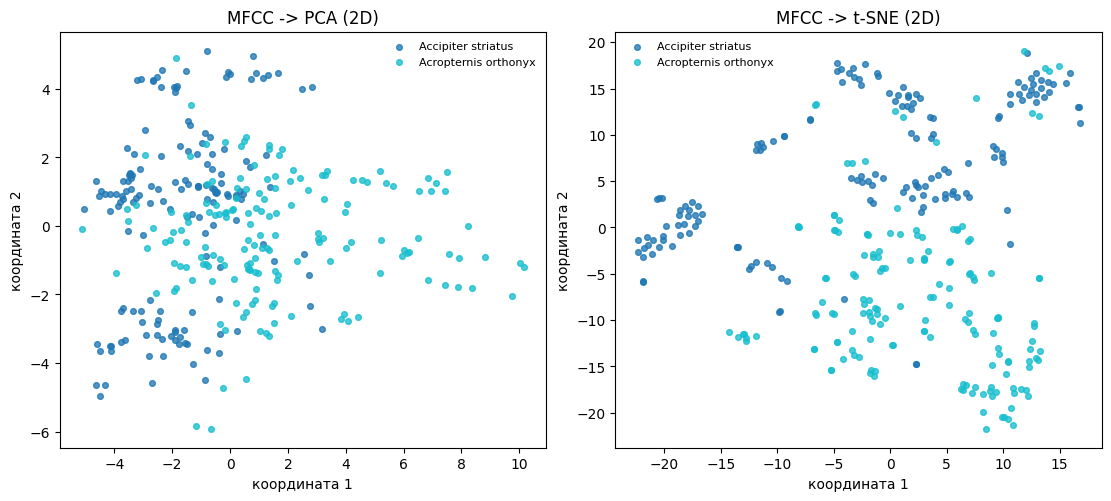

In [48]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder, StandardScaler

le_viz = LabelEncoder()
y_train_idx = le_viz.fit_transform(y_train)

scaler_viz = StandardScaler()
Xz = scaler_viz.fit_transform(X_train_mfcc)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(Xz)

perplexity = min(30, len(Xz) - 1)
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    max_iter=1000,
    random_state=SEED,
    init="pca",
)
X_tsne = tsne.fit_transform(Xz)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.9), constrained_layout=True)
class_names = le_viz.classes_
pal = plt.cm.tab10(np.linspace(0, 0.91, len(class_names)))

for ax, X2d, title in (
    (axes[0], X_pca, "MFCC -> PCA (2D)"),
    (axes[1], X_tsne, "MFCC -> t-SNE (2D)"),
):
    for k, name in enumerate(class_names):
        mask = y_train_idx == k
        ax.scatter(
            X2d[mask, 0],
            X2d[mask, 1],
            s=17,
            alpha=0.78,
            label=name,
            color=pal[k],
        )
    ax.set_title(title)
    ax.set_xlabel("координата 1")
    ax.set_ylabel("координата 2")
    ax.legend(frameon=False, fontsize=8)

plt.show()

## Пункт 4

Выберете любую метрику для оценки задачи классификации. Вычислите качество работы любых нескольких (не менее трёх) классических моделей машинного обучения.

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

le_clf = LabelEncoder()
y_train_enc = le_clf.fit_transform(y_train)
y_test_enc = le_clf.transform(y_test)

scaler_clf = StandardScaler()
X_tr = scaler_clf.fit_transform(X_train_mfcc)
X_te = scaler_clf.transform(X_test_mfcc)

models = {
    "log_reg": LogisticRegression(max_iter=1000, random_state=SEED),
    "rf": RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    "svc_rbf": SVC(kernel="rbf", gamma="scale", random_state=SEED),
}

for name, clf in models.items():
    clf.fit(X_tr, y_train_enc)
    pred = clf.predict(X_te)
    score = f1_score(y_test_enc, pred, average="macro")
    print(f"{name}: F1_macro = {score:.4f}")

log_reg: F1_macro = 0.9495
rf: F1_macro = 0.9747
svc_rbf: F1_macro = 0.9620


## Пункт 5

Скачайте любую предобученную модель глубокого обучения для извлечения признаков из аудио. Обратите внимание на то, работает ли моделей с сырым аудио или со спектрограммой, какая частота дискретизации для неё требуется, извлекает ли модель вектор или последовательность векторов как во 2-м пункте. Повторите пункты 3 и 4 для признаков извлечённых этой моделью.

Используем `facebook/wav2vec2-base` (HuggingFace `transformers`)

In [50]:
%pip install -q "transformers>=4.30.0" safetensors torchaudio
import torch
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model

W2V_MODEL_NAME = "facebook/wav2vec2-base"
W2V_SAMPLE_RATE = 16_000

feature_extractor_w2v = Wav2Vec2FeatureExtractor.from_pretrained(W2V_MODEL_NAME)
model_w2v = Wav2Vec2Model.from_pretrained(W2V_MODEL_NAME)
model_w2v.eval()

device = (torch.device("mps"))
model_w2v.to(device)


def w2v_vector(example: dict) -> np.ndarray:
    y, sr = _wav_mono_from_bytes(example["audio"])
    if sr != W2V_SAMPLE_RATE:
        y = librosa.resample(y, orig_sr=sr, target_sr=W2V_SAMPLE_RATE)
    inputs = feature_extractor_w2v(
        y, sampling_rate=W2V_SAMPLE_RATE, return_tensors="pt", padding=False
    )
    with torch.no_grad():
        hidden = model_w2v(inputs.input_values.to(device)).last_hidden_state
    return hidden.squeeze(0).mean(dim=0).cpu().numpy().astype(np.float32)


def build_w2v_matrix(ds) -> np.ndarray:
    return np.stack([w2v_vector(ds[i]) for i in range(len(ds))])


X_train_w2v = build_w2v_matrix(train_ds)
X_test_w2v = build_w2v_matrix(test_ds)
print("X_train_w2v:", X_train_w2v.shape, "  X_test_w2v:", X_test_w2v.shape)

Note: you may need to restart the kernel to use updated packages.


/Users/moahim/Library/Python/3.9/lib/python/site-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


X_train_w2v: (320, 768)   X_test_w2v: (80, 768)


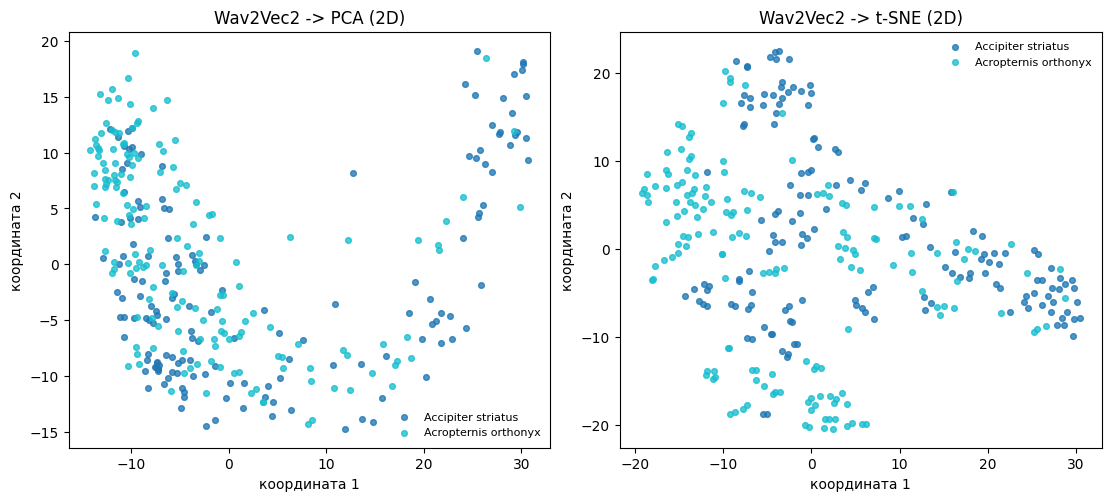

log_reg: F1_macro = 0.8866
rf: F1_macro = 0.9101
svc_rbf: F1_macro = 0.9226


In [51]:
def _plot_projections(X_pca, X_tsne, y_idx, class_names, title_prefix):
    pal = plt.cm.tab10(np.linspace(0, 0.91, len(class_names)))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.9), constrained_layout=True)
    for ax, X2d, suffix in (
        (axes[0], X_pca, "PCA (2D)"),
        (axes[1], X_tsne, "t-SNE (2D)"),
    ):
        for k, name in enumerate(class_names):
            mask = y_idx == k
            ax.scatter(
                X2d[mask, 0], X2d[mask, 1],
                s=17, alpha=0.78, label=name, color=pal[k],
            )
        ax.set_title(f"{title_prefix} -> {suffix}")
        ax.set_xlabel("координата 1")
        ax.set_ylabel("координата 2")
        ax.legend(frameon=False, fontsize=8)
    plt.show()

scaler_w2v = StandardScaler()
Xz_w2v = scaler_w2v.fit_transform(X_train_w2v)

X_pca_w2v = PCA(n_components=2, random_state=SEED).fit_transform(Xz_w2v)

perplexity_w2v = min(30, len(Xz_w2v) - 1)
X_tsne_w2v = TSNE(
    n_components=2, perplexity=perplexity_w2v,
    max_iter=1000, random_state=SEED, init="pca",
).fit_transform(Xz_w2v)

_plot_projections(X_pca_w2v, X_tsne_w2v, le_viz.transform(y_train), le_viz.classes_, "Wav2Vec2")

X_tr_w2v = scaler_w2v.transform(X_train_w2v)
X_te_w2v = scaler_w2v.transform(X_test_w2v)

for name, clf in {
    "log_reg": LogisticRegression(max_iter=1000, random_state=SEED),
    "rf": RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    "svc_rbf": SVC(kernel="rbf", gamma="scale", random_state=SEED),
}.items():
    clf.fit(X_tr_w2v, y_train_enc)
    print(f"{name}: F1_macro = {f1_score(y_test_enc, clf.predict(X_te_w2v), average='macro'):.4f}")

## Пункт 6

Обучите модель глубокого обучения для задачи классификации. Это должна быть классификационная голова для модели извлечения признаков. Вычислите качество работы полученного классификатора.

In [52]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

NUM_CLASSES = len(le_clf.classes_)
BATCH_SIZE = 30
NUM_EPOCHS_HEAD = 12
LR_HEAD = 1e-3

X_tr_t = torch.from_numpy(X_train_w2v)
y_tr_t = torch.tensor(y_train_enc, dtype=torch.long)
X_te_t = torch.from_numpy(X_test_w2v)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)

W2V_HIDDEN = model_w2v.config.hidden_size

model_w2v.requires_grad_(False)
clf_head = nn.Linear(W2V_HIDDEN, NUM_CLASSES).to(device)
optimizer_head = torch.optim.Adam(clf_head.parameters(), lr=LR_HEAD)
criterion = nn.CrossEntropyLoss()

for epoch in tqdm(range(NUM_EPOCHS_HEAD), desc="head"):
    clf_head.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_head.zero_grad()
        criterion(clf_head(xb), yb).backward()
        optimizer_head.step()

clf_head.eval()
with torch.no_grad():
    preds_head = clf_head(X_te_t.to(device)).argmax(dim=1).cpu().numpy()

print(f"dl_head: F1_macro = {f1_score(y_test_enc, preds_head, average='macro'):.4f}")

head: 100%|██████████| 12/12 [00:00<00:00, 50.56it/s]

dl_head: F1_macro = 0.8834


## Пункт 7

Разморозьте параметры модели извлечения признаков из 5-го пункта, и дообучите вместе с моделью из 6-го пункта. Повторите пункты 3 и 4 для дообученных моделей извлечения признаков и классификации.

In [53]:
NUM_EPOCHS_FT = 5
LR_W2V_FT = 1e-5


class _RawAudioDataset(torch.utils.data.Dataset):
    def __init__(self, ds):
        self.ds = ds

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        row = self.ds[idx]
        y, sr = _wav_mono_from_bytes(row["audio"])
        if sr != W2V_SAMPLE_RATE:
            y = librosa.resample(y, orig_sr=sr, target_sr=W2V_SAMPLE_RATE)
        label = le_clf.transform([row[label_key]])[0]
        return torch.tensor(y, dtype=torch.float32), label


def _collate_single(batch):
    y_t, label = batch[0]
    inp = feature_extractor_w2v(
        y_t.numpy(), sampling_rate=W2V_SAMPLE_RATE, return_tensors="pt", padding=False,
    )
    return inp.input_values, torch.tensor([label], dtype=torch.long)


model_w2v.requires_grad_(True)
optimizer_ft = torch.optim.Adam([
    {"params": model_w2v.parameters(), "lr": LR_W2V_FT},
    {"params": clf_head.parameters(), "lr": LR_HEAD},
])

ft_loader = DataLoader(
    _RawAudioDataset(train_ds),
    batch_size=1,
    shuffle=True,
    collate_fn=_collate_single,
    generator=torch.Generator().manual_seed(SEED),
)

for epoch in tqdm(range(NUM_EPOCHS_FT), desc="finetune"):
    model_w2v.train()
    clf_head.train()
    total_loss = 0.0
    for input_values, yb in ft_loader:
        optimizer_ft.zero_grad()
        hidden = model_w2v(input_values.to(device)).last_hidden_state
        feat = hidden.squeeze(0).mean(dim=0, keepdim=True)
        loss = criterion(clf_head(feat), yb.to(device))
        loss.backward()
        optimizer_ft.step()
        total_loss += loss.item()
    tqdm.write(f"epoch {epoch + 1}: loss={total_loss / len(ft_loader):.4f}")

finetune:  20%|██        | 1/5 [00:53<03:32, 53.02s/it]

epoch 1: loss=0.3451


finetune:  40%|████      | 2/5 [01:46<02:39, 53.24s/it]

epoch 2: loss=0.1655


finetune:  60%|██████    | 3/5 [02:39<01:46, 53.28s/it]

epoch 3: loss=0.0723


finetune:  80%|████████  | 4/5 [03:34<00:53, 53.68s/it]

epoch 4: loss=0.1170


finetune: 100%|██████████| 5/5 [04:27<00:00, 53.58s/it]

epoch 5: loss=0.0513


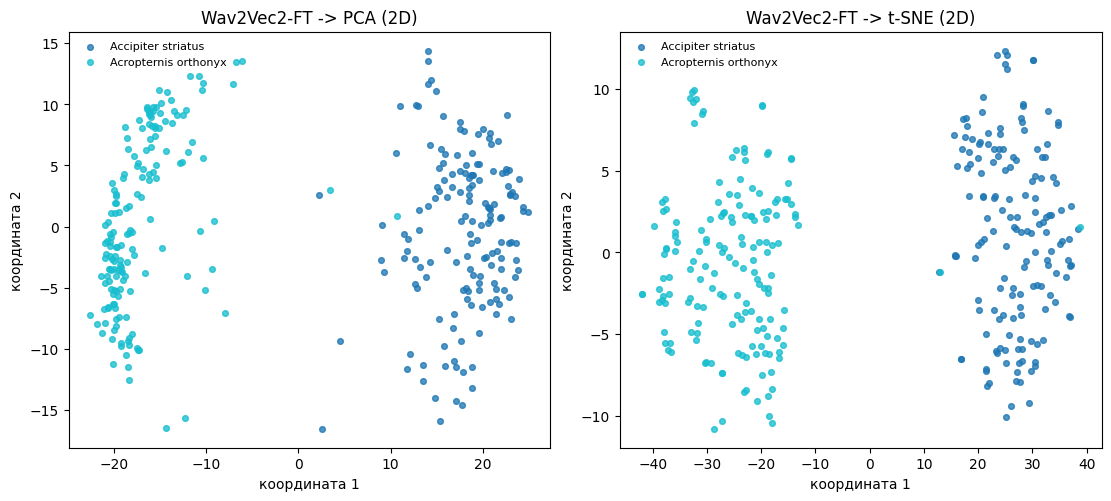

log_reg: F1_macro = 0.987340
rf: F1_macro = 0.987340
svc_rbf: F1_macro = 0.987340
dl_head_ft: F1_macro = 0.9873


In [54]:
model_w2v.eval()
clf_head.eval()

X_train_ft = build_w2v_matrix(train_ds)
X_test_ft = build_w2v_matrix(test_ds)

scaler_ft = StandardScaler()
Xz_ft = scaler_ft.fit_transform(X_train_ft)

X_pca_ft = PCA(n_components=2, random_state=SEED).fit_transform(Xz_ft)
perp_ft = min(30, len(Xz_ft) - 1)
X_tsne_ft = TSNE(
    n_components=2, perplexity=perp_ft,
    max_iter=1000, random_state=SEED, init="pca",
).fit_transform(Xz_ft)

_plot_projections(X_pca_ft, X_tsne_ft, le_viz.transform(y_train), le_viz.classes_, "Wav2Vec2-FT")

X_tr_ft = scaler_ft.transform(X_train_ft)
X_te_ft = scaler_ft.transform(X_test_ft)

for name, clf in {
    "log_reg": LogisticRegression(max_iter=1000, random_state=SEED),
    "rf": RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    "svc_rbf": SVC(kernel="rbf", gamma="scale", random_state=SEED),
}.items():
    clf.fit(X_tr_ft, y_train_enc)
    print(f"{name}: F1_macro = {f1_score(y_test_enc, clf.predict(X_te_ft), average='macro'):.6f}")

with torch.no_grad():
    preds_ft_dl = clf_head(
        torch.from_numpy(X_test_ft).to(device)
    ).argmax(dim=1).cpu().numpy()
print(f"dl_head_ft: F1_macro = {f1_score(y_test_enc, preds_ft_dl, average='macro'):.4f}")

## Пункт 8

По результатам экспериментов выберете лучшее признаковое пространство. Найдите в нём две самые близкие и две самые дальние  аудиозаписи. Визуализируйте спектрограммы этих аудиозаписей.

In [55]:
from sklearn.metrics.pairwise import euclidean_distances

spaces = {
    "MFCC":       (X_tr,     X_te,     X_test_mfcc),
    "Wav2Vec2":   (X_tr_w2v, X_te_w2v, X_test_w2v),
    "Wav2Vec2-FT":(X_tr_ft,  X_te_ft,  X_test_ft),
}

best_name, best_score, best_X_test_raw = None, -1.0, None
for name, (X_tr_s, X_te_s, X_test_raw) in spaces.items():
    svc = SVC(kernel="rbf", gamma="scale", random_state=SEED)
    svc.fit(X_tr_s, y_train_enc)
    score = f1_score(y_test_enc, svc.predict(X_te_s), average="macro")
    print(f"{name}: F1_macro = {score:.4f}")
    if score > best_score:
        best_score, best_name, best_X_test_raw = score, name, X_test_raw

print(f"\nЛучшее пространство: {best_name}  (F1={best_score:.4f})")

dist_matrix = euclidean_distances(best_X_test_raw)

mask = np.triu(np.ones(dist_matrix.shape, dtype=bool), k=1)
flat_i, flat_j = np.where(mask)
flat_d = dist_matrix[mask]

order = np.argsort(flat_d)
closest_i,  closest_j  = flat_i[order[0]],  flat_j[order[0]]
farthest_i, farthest_j = flat_i[order[-1]], flat_j[order[-1]]

print(f"\nБлижайшая пара : test[{closest_i}] — test[{closest_j}]  d={flat_d[order[0]]:.4f}")
print(f"Дальнейшая пара: test[{farthest_i}] — test[{farthest_j}]  d={flat_d[order[-1]]:.4f}")

MFCC: F1_macro = 0.9620
Wav2Vec2: F1_macro = 0.9226
Wav2Vec2-FT: F1_macro = 0.9873

Лучшее пространство: Wav2Vec2-FT  (F1=0.9873)

Ближайшая пара : test[37] — test[69]  d=1.6889
Дальнейшая пара: test[35] — test[56]  d=13.7975


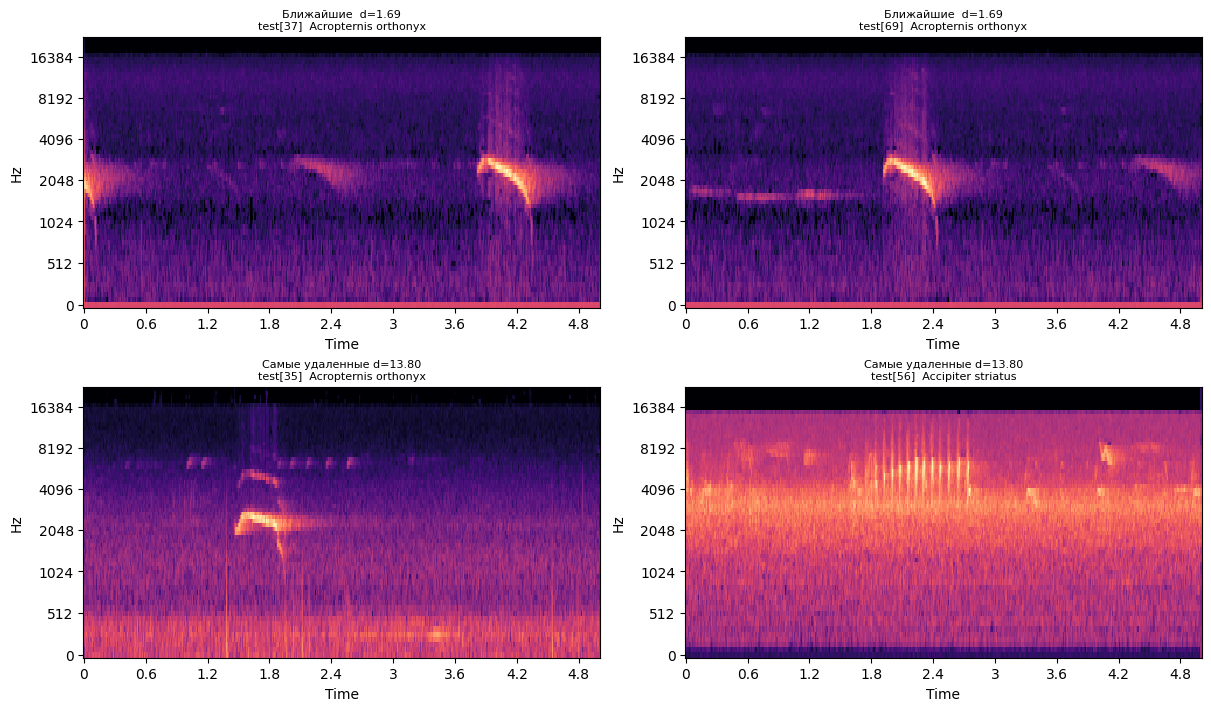

In [56]:
import librosa.display

N_MELS = 64

def _plot_mel(ax, example, title):
    y, sr = _wav_mono_from_bytes(example["audio"])
    S_db = librosa.power_to_db(
        librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS,
        ),
        ref=np.max,
    )
    img = librosa.display.specshow(
        S_db, sr=sr, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel", ax=ax,
    )
    ax.set_title(title, fontsize=8)


pairs = [
    (closest_i,  closest_j,  f"Ближайшие  d={flat_d[order[0]]:.2f}"),
    (farthest_i, farthest_j, f"Самые удаленные d={flat_d[order[-1]]:.2f}"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

for row, (idx_a, idx_b, group) in enumerate(pairs):
    ex_a = test_ds[int(idx_a)]
    ex_b = test_ds[int(idx_b)]
    _plot_mel(axes[row][0], ex_a, f"{group}\ntest[{idx_a}]  {ex_a[label_key]}")
    _plot_mel(axes[row][1], ex_b, f"{group}\ntest[{idx_b}]  {ex_b[label_key]}")

plt.show()